<a href="https://colab.research.google.com/github/sauraviitj/HopeLens/blob/main/scripts/04_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install scipy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from scipy.stats import spearmanr

In [ ]:
songs = pd.read_csv(
    "/content/drive/MyDrive/HopeLens/Data/metadata/song_semantic.csv"
)

songs.head()

,#,Song,filename,Category,Artist,semantic_category,Your Score,Nibedita Score,Tula Score,Human Mean,AI Score
0,1,Fix You,fix_you.txt,Healing,Coldplay,Very High,8.0,7.50,7.0,7.50,NaN
1,2,Up&Up,Up&up.txt,Perseverance,Coldplay,Very High,8.5,8.75,9.0,8.75,NaN
2,3,Paradise,paradise.txt,Hope & Escape,Coldplay,High,7.0,6.50,6.0,6.50,NaN
3,4,The Scientist,thescientist.txt,Regret & Reflection,Coldplay,Medium–High,6.8,6.80,6.8,6.80,NaN
4,5,Everglow,everglow.txt,Love & Loss,Coldplay,Medium–High,7.0,6.00,5.0,6.00,NaN


In [ ]:
songs["Human Score"] = (
    songs["Your Score"] +
    songs["Nibedita Score"] +
    songs["Tula Score"]
)/3

In [ ]:
ai = pd.read_csv(
    "/content/drive/MyDrive/HopeLens/results/semantic_hope_index.csv"
)

In [ ]:
df = songs.merge(
    ai[["Song","SHI"]],
    on="Song"
)

df.head()

,#,Song,filename,Category,Artist,semantic_category,Your Score,Nibedita Score,Tula Score,Human Mean,AI Score,Human Score,SHI
0,1,Fix You,fix_you.txt,Healing,Coldplay,Very High,8.0,7.50,7.0,7.50,NaN,7.50,40.843597
1,2,Up&Up,Up&up.txt,Perseverance,Coldplay,Very High,8.5,8.75,9.0,8.75,NaN,8.75,40.004536
2,3,Paradise,paradise.txt,Hope & Escape,Coldplay,High,7.0,6.50,6.0,6.50,NaN,6.50,39.646990
3,4,The Scientist,thescientist.txt,Regret & Reflection,Coldplay,Medium–High,6.8,6.80,6.8,6.80,NaN,6.80,37.065174
4,5,Everglow,everglow.txt,Love & Loss,Coldplay,Medium–High,7.0,6.00,5.0,6.00,NaN,6.00,41.039436


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

# Normalize SHI to a 1-10 scale
scaler = MinMaxScaler(feature_range=(1,10))

df["AI Score"] = scaler.fit_transform(df[["SHI"]])

# Compute MAE
mae = mean_absolute_error(
    df["Human Score"],
    df["AI Score"]
)

print(f"MAE: {mae:.3f}")

MAE: 2.134


In [ ]:
from scipy.stats import spearmanr

spearman, p = spearmanr(
    df["Human Score"],
    df["AI Score"]
)

print(f"Spearman: {spearman:.3f}")
print(f"p-value: {p:.4f}")

Spearman: 0.362
p-value: 0.0758


In [ ]:
from scipy.stats import pearsonr

pearson, p = pearsonr(
    df["Human Score"],
    df["AI Score"]
)

print(f"Pearson: {pearson:.3f}")
print(f"p-value: {p:.4f}")

Pearson: 0.541
p-value: 0.0052


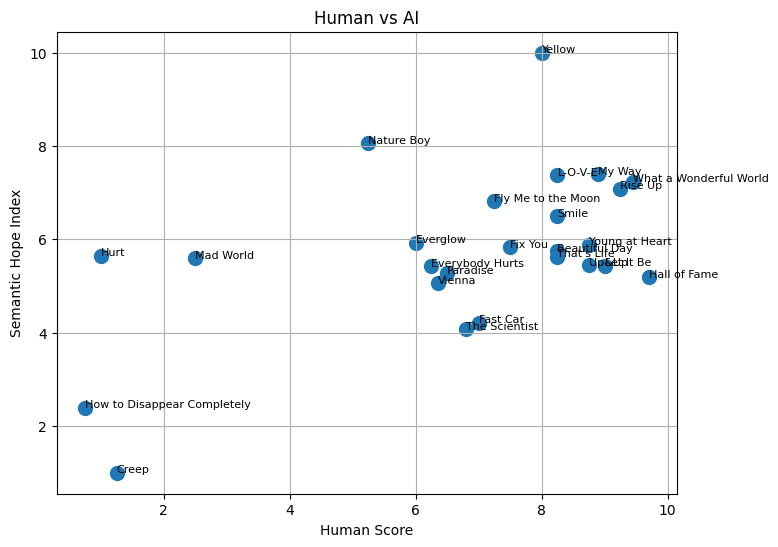

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Human Score"],
    df["AI Score"],
    s=100
)

for _, row in df.iterrows():

    plt.text(
        row["Human Score"],
        row["AI Score"],
        row["Song"],
        fontsize=8
    )

plt.xlabel("Human Score")

plt.ylabel("Semantic Hope Index")

plt.title("Human vs AI")

plt.grid(True)

plt.show()

In [ ]:
df["Error"] = abs(
    df["Human Score"] -
    df["AI Score"]
)

comparison = df[[
    "Song",
    "Human Score",
    "AI Score",
    "Error"
]]

comparison.sort_values("Error", ascending=False)

,Song,Human Score,AI Score,Error
23,Hurt,1.00,5.647861,4.647861
9,Hall of Fame,9.70,5.185524,4.514476
10,Let It Be,9.00,5.434772,3.565228
1,Up&Up,8.75,5.445611,3.304389
21,Mad World,2.50,5.603177,3.103177
14,Young at Heart,8.75,5.883976,2.866024
17,Nature Boy,5.25,8.061534,2.811534
19,Fast Car,7.00,4.217632,2.782368
3,The Scientist,6.80,4.070004,2.729996
11,That's Life,8.25,5.625172,2.624828


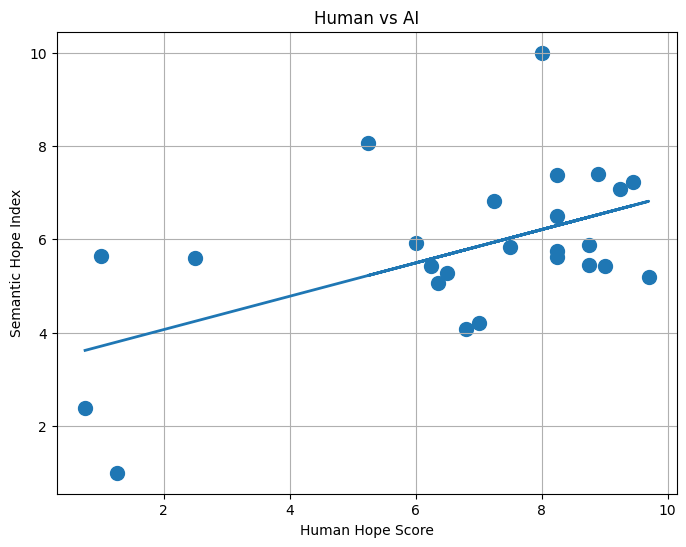

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["Human Score"], df["AI Score"], s=100)

m, b = np.polyfit(
    df["Human Score"],
    df["AI Score"],
    1
)

plt.plot(
    df["Human Score"],
    m*df["Human Score"]+b,
    linewidth=2
)

plt.xlabel("Human Hope Score")
plt.ylabel("Semantic Hope Index")
plt.title("Human vs AI")

plt.grid(True)

plt.show()

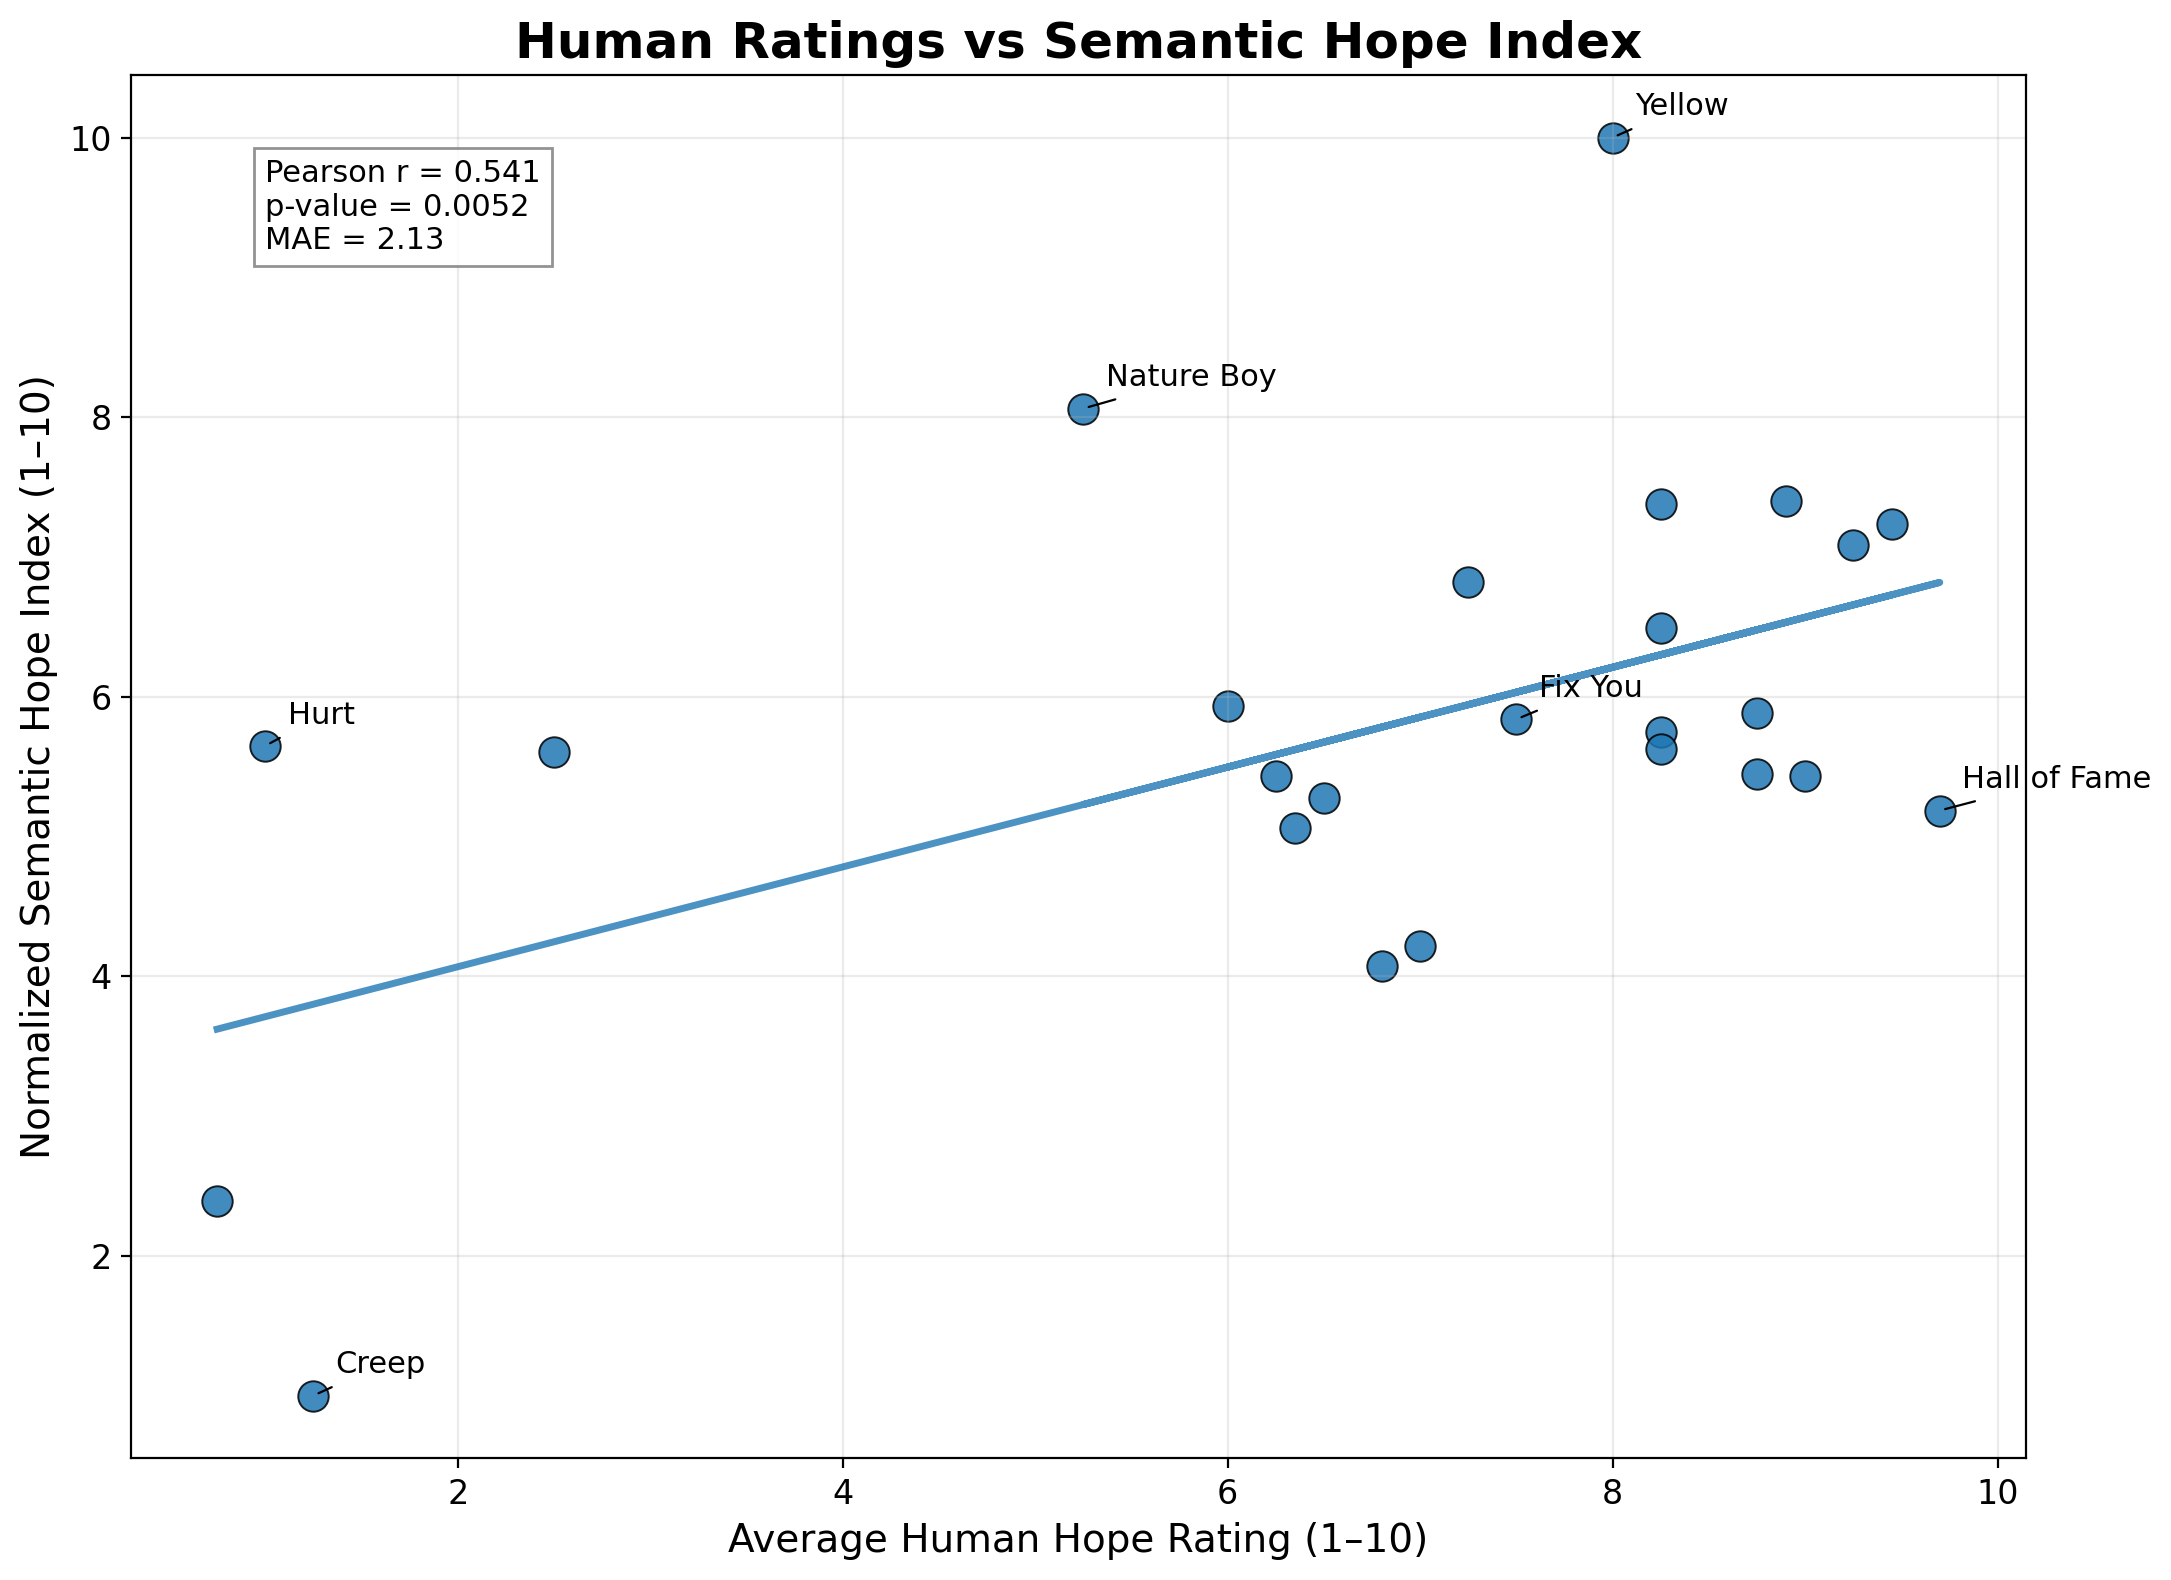

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# -----------------------------
# DATA
# -----------------------------

x = df["Human Score"]
y = df["AI Score"]

# -----------------------------
# FIGURE
# -----------------------------

plt.figure(figsize=(11,8), dpi=200)

# Scatter points
plt.scatter(
    x,
    y,
    s=120,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.7
)

# -----------------------------
# Regression line
# -----------------------------

m, b = np.polyfit(x, y, 1)

plt.plot(
    x,
    m*x+b,
    linewidth=2.5,
    alpha=0.8
)

# -----------------------------
# Highlight important songs
# -----------------------------

important = [
    "Yellow",
    "Nature Boy",
    "Hall of Fame",
    "Hurt",
    "Creep",
    "Fix You",
]

for i,row in df.iterrows():

    if row["Song"] in important:

        plt.annotate(
            row["Song"],
            (row["Human Score"], row["AI Score"]),
            xytext=(8,8),
            textcoords="offset points",
            fontsize=11,
            arrowprops=dict(
                arrowstyle="-",
                lw=0.8
            )
        )

# -----------------------------
# Correlation box
# -----------------------------

pearson,p = pearsonr(x,y)

text = (
    f"Pearson r = {pearson:.3f}\n"
    f"p-value = {p:.4f}\n"
    f"MAE = 2.13"
)

plt.text(
    1.0,
    9.2,
    text,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        alpha=0.85,
        edgecolor="gray"
    )
)

# -----------------------------
# Labels
# -----------------------------

plt.title(
    "Human Ratings vs Semantic Hope Index",
    fontsize=18,
    weight="bold"
)

plt.xlabel(
    "Average Human Hope Rating (1–10)",
    fontsize=14
)

plt.ylabel(
    "Normalized Semantic Hope Index (1–10)",
    fontsize=14
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "human_vs_shi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

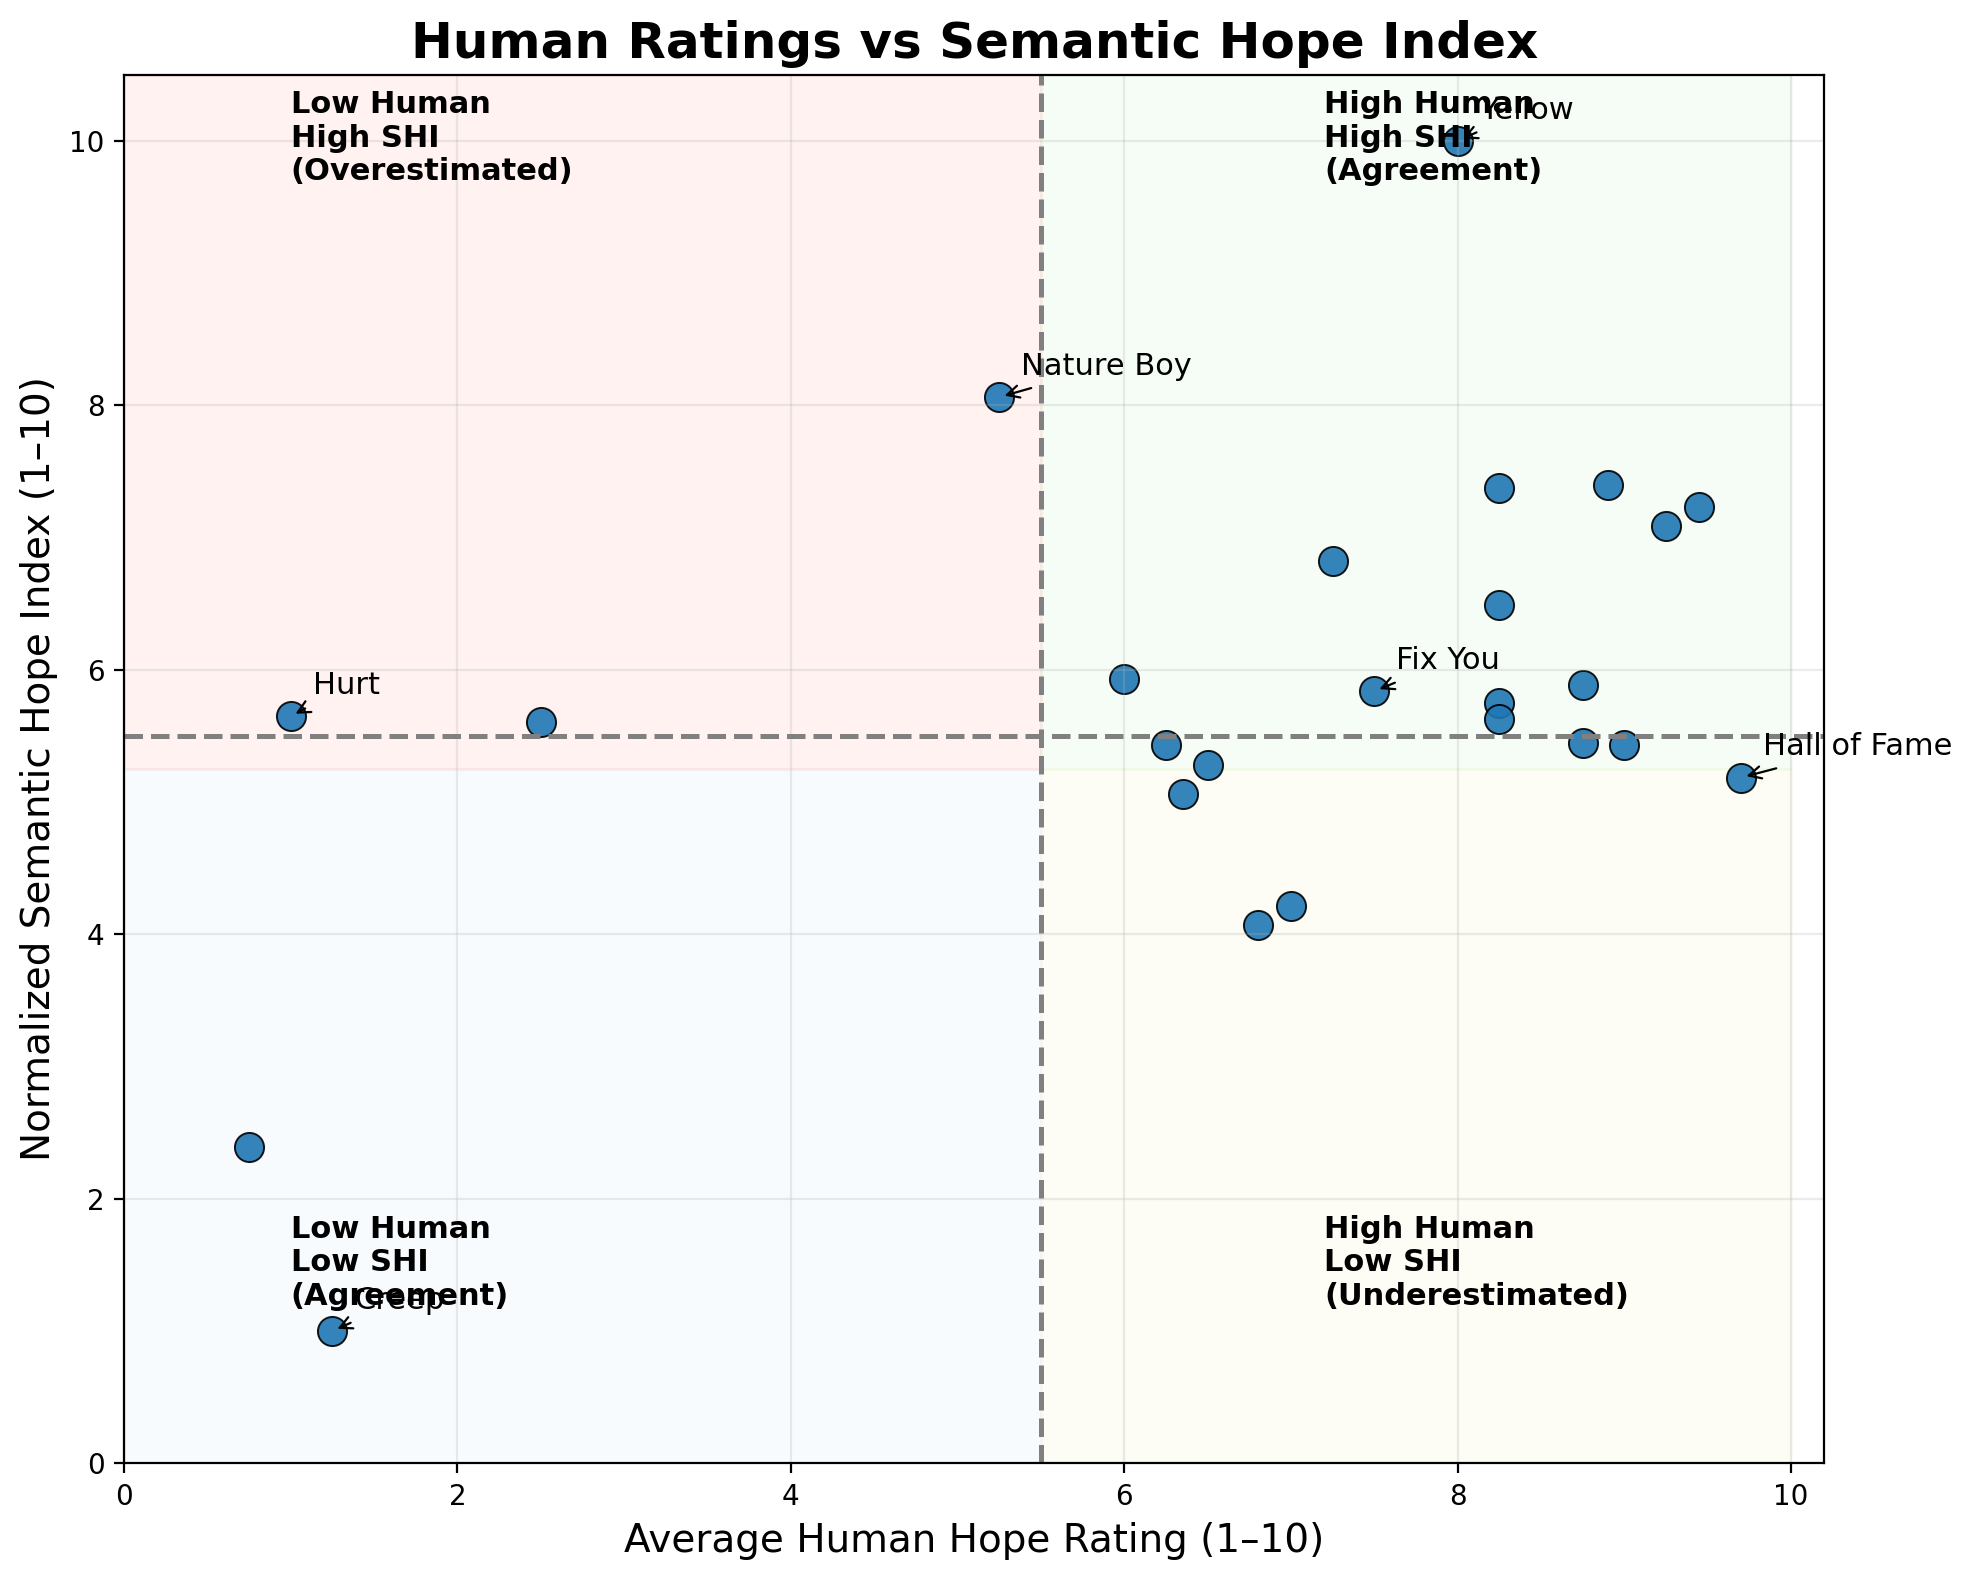

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# DATA
# ----------------------------

x = df["Human Score"]
y = df["AI Score"]

songs = df["Song"]

# ----------------------------
# QUADRANT THRESHOLDS
# ----------------------------

x_mid = 5.5
y_mid = 5.5

# ----------------------------
# FIGURE
# ----------------------------

plt.figure(figsize=(10,8), dpi=200)

# ---- Background quadrants ----

plt.axvspan(0, x_mid, ymin=0.5, ymax=1,
            alpha=0.08, color="tomato")

plt.axvspan(x_mid, 10, ymin=0.5, ymax=1,
            alpha=0.08, color="lightgreen")

plt.axvspan(0, x_mid, ymin=0, ymax=0.5,
            alpha=0.08, color="lightblue")

plt.axvspan(x_mid, 10, ymin=0, ymax=0.5,
            alpha=0.08, color="khaki")

# ----------------------------
# Scatter
# ----------------------------

plt.scatter(
    x,
    y,
    s=110,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.9
)

# ----------------------------
# Quadrant Lines
# ----------------------------

plt.axvline(
    x_mid,
    linestyle="--",
    linewidth=1.8,
    color="gray"
)

plt.axhline(
    y_mid,
    linestyle="--",
    linewidth=1.8,
    color="gray"
)

# ----------------------------
# Annotate interesting songs
# ----------------------------

important = [
    "Yellow",
    "Hall of Fame",
    "Nature Boy",
    "Hurt",
    "Creep",
    "Fix You",
]

for i,row in df.iterrows():

    if row["Song"] in important:

        plt.annotate(
            row["Song"],
            xy=(row["Human Score"], row["AI Score"]),
            xytext=(8,8),
            textcoords="offset points",
            fontsize=11,
            arrowprops=dict(
                arrowstyle="->",
                lw=0.8
            )
        )

# ----------------------------
# Quadrant Labels
# ----------------------------

plt.text(
    1,
    9.7,
    "Low Human\nHigh SHI\n(Overestimated)",
    fontsize=11,
    weight="bold"
)

plt.text(
    7.2,
    9.7,
    "High Human\nHigh SHI\n(Agreement)",
    fontsize=11,
    weight="bold"
)

plt.text(
    1,
    1.2,
    "Low Human\nLow SHI\n(Agreement)",
    fontsize=11,
    weight="bold"
)

plt.text(
    7.2,
    1.2,
    "High Human\nLow SHI\n(Underestimated)",
    fontsize=11,
    weight="bold"
)

# ----------------------------
# Axis labels
# ----------------------------

plt.xlim(0,10.2)
plt.ylim(0,10.5)

plt.xlabel(
    "Average Human Hope Rating (1–10)",
    fontsize=14
)

plt.ylabel(
    "Normalized Semantic Hope Index (1–10)",
    fontsize=14
)

plt.title(
    "Human Ratings vs Semantic Hope Index",
    fontsize=18,
    weight="bold"
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "quadrant_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()